# CellorNuc Starter Quiz - reproducible 6k analysis

This notebook implements Q1, Q2, and Q3 on the supplied 6k datasets. It preserves the original questions, records all model settings, generates figures and compact result tables, and gives answers immediately after the supporting outputs.

The notebook uses the 6k files for a reproducible development-scale analysis. It does not claim that subsample estimates must exactly equal full-data estimates.

## Analysis conventions

Three related but distinct fits are used:

- **Q1:** the mixed-data pattern from the official demo: anchored global fit, raw counts, `gamma_hi=0.95`, and `gamma_lo=0.05`, without hard component-mean constraints.
- **Q2:** the official demo's sc-only pattern: anchored global fit with `max_p_nuc=0.2` and `min_p_cell=0.8`.
- **Q3:** the question's default-parameter initialization experiment: no hard component-mean constraints, with only `init='anchored'` versus `init='split'` changed. The raw-count layer, `copy=True`, and quiet printing are operational choices rather than model constraints.

This separation matters because initialization anchors and component-mean constraints are not the same mechanism.

In [1]:
%matplotlib inline
from pathlib import Path
from importlib.metadata import version
import hashlib
import sys
import warnings

import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

PROJECT_ROOT = next(
    (
        candidate
        for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (candidate / "data").is_dir() and (candidate / "scanpyplus").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the CellorNuc repository root.")

sys.path.insert(0, str(PROJECT_ROOT))
from scanpyplus import Scanpyplus

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR.mkdir(exist_ok=True)
for question in ("q1", "q2", "q3"):
    (RESULTS_DIR / question).mkdir(parents=True, exist_ok=True)

MIXED_PATH = DATA_DIR / "mixed_mBDRC_5pCells_multiomeNuclei_6k.h5ad"
SINGLE_PATH = DATA_DIR / "single_KidneyRaji_sc_6k.h5ad"

MIN_COUNTS = 10
GAMMA_HI = 0.95
GAMMA_LO = 0.05
RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

sc.settings.set_figure_params(dpi=110, facecolor="white", figsize=(5, 5))
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 6)

print(f"Project located: {PROJECT_ROOT.name}")
print(f"Python: {sys.version.split()[0]}")
for package in ("scanpy", "anndata", "numpy", "pandas", "scipy", "scikit-learn"):
    print(f"{package}: {version(package)}")

Project located: CellorNuc
Python: 3.11.15
scanpy: 1.11.5
anndata: 0.12.19
numpy: 2.4.6
pandas: 2.3.3
scipy: 1.17.1
scikit-learn: 1.9.0


In [2]:
def sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


input_manifest = pd.DataFrame(
    [
        {
            "dataset": "A: mixed",
            "file": MIXED_PATH.name,
            "size_MiB": MIXED_PATH.stat().st_size / 2**20,
            "sha256": sha256(MIXED_PATH),
        },
        {
            "dataset": "B: sc only",
            "file": SINGLE_PATH.name,
            "size_MiB": SINGLE_PATH.stat().st_size / 2**20,
            "sha256": sha256(SINGLE_PATH),
        },
    ]
).set_index("dataset")
input_manifest

,file,size_MiB,sha256
dataset,,,
A: mixed,mixed_mBDRC_5pCells_multiomeNuclei_6k.h5ad,60.465954,665be43625cca4f23d899bea5fcb98ddc3e408a04a6846...
B: sc only,single_KidneyRaji_sc_6k.h5ad,46.740710,beb1d1399f08c51e9ff7d802735d047005ea1fd3e065a8...


The SHA-256 values make the exact 6k input files identifiable. If a file changes, the notebook's numerical outputs may also change.

In [3]:
sc_genes, sn_genes = Scanpyplus.LoadGeneSignatures()

print(f"sc signature ({len(sc_genes)} genes): {sc_genes}")
print(f"sn signature ({len(sn_genes)} genes): {sn_genes}")


def signature_overlap(adata):
    return pd.DataFrame(
        {
            "supplied": [len(sc_genes), len(sn_genes)],
            "found": [
                sum(g in adata.var_names for g in sc_genes),
                sum(g in adata.var_names for g in sn_genes),
            ],
            "missing": [
                [g for g in sc_genes if g not in adata.var_names],
                [g for g in sn_genes if g not in adata.var_names],
            ],
        },
        index=pd.Index(["sc", "sn"], name="signature"),
    )


def global_fit_summary(adata):
    fit = adata.uns["modality_em"]["global"]
    a_cell, b_cell = fit["ab_cell"]
    a_nuc, b_nuc = fit["ab_nuc"]
    p_cell_component = a_cell / (a_cell + b_cell)
    p_nuc_component = a_nuc / (a_nuc + b_nuc)
    return pd.Series(
        {
            "p_cell_component": p_cell_component,
            "p_nucleus_component": p_nuc_component,
            "cell_concentration": a_cell + b_cell,
            "nucleus_concentration": a_nuc + b_nuc,
            "lam_cell": fit["lam_cell"],
            "component_separation": p_cell_component - p_nuc_component,
            "bic_1": fit["bic_1"],
            "bic_2": fit["bic_2"],
            "delta_bic_bic1_minus_bic2": fit["bic_1"] - fit["bic_2"],
            "loglik": fit["loglik"],
        }
    )

sc signature (10 genes): ['EEF1A1', 'TPT1', 'FTH1', 'FTL', 'SERF2', 'ATP5F1E', 'GAPDH', 'UBA52', 'COX7C', 'MIF']
sn signature (10 genes): ['FTX', 'AGAP1', 'GMDS-DT', 'PARD3', 'WWOX', 'MAGI2', 'PKHD1', 'NHS', 'AC098829.1', 'DPP6']


In [4]:
mixed_input = sc.read_h5ad(MIXED_PATH)
single_input = ad.read_h5ad(SINGLE_PATH)

input_shapes = pd.DataFrame(
    {
        "n_obs": [mixed_input.n_obs, single_input.n_obs],
        "n_vars": [mixed_input.n_vars, single_input.n_vars],
        "layers": [list(mixed_input.layers.keys()), list(single_input.layers.keys())],
        "embeddings": [list(mixed_input.obsm.keys()), list(single_input.obsm.keys())],
    },
    index=["A: mixed", "B: sc only"],
)
display(input_shapes)
print("Mixed signature overlap:")
display(signature_overlap(mixed_input))
print("Single-modality signature overlap:")
display(signature_overlap(single_input))

,n_obs,n_vars,layers,embeddings
A: mixed,6000,29987,[counts],[X_umap]
B: sc only,6000,28562,[counts],[X_umap]


Mixed signature overlap:


,supplied,found,missing
signature,,,
sc,10,10,[]
sn,10,9,[AC098829.1]


Single-modality signature overlap:


,supplied,found,missing
signature,,,
sc,10,10,[]
sn,10,10,[]


# Q1. Run the classifier on the mixed dataset A (cells + nuclei)

> Download dataset A and run `CellorNucEM` on the mixed dataset A.
>
> **1a.** Are any cell droplets called Typical Nucleus (SN), or any nucleus droplets called Typical Cell (SC)? How well does the signature work on this independent dataset?
>
> **1b.** Look at the distribution of `obs['modality_counts']` in cells vs nuclei and, together with the parameter `min_counts=10`, explain where these Neutral calls come from. What are the probable reasons for the Neutral calls?

## Q1 implementation

Dataset A records biological modality in `obs['suspension_type']` using the exact values `cell` and `nucleus`. Its `obs['assay']` column instead contains sequencing technologies, so `suspension_type` is the correct metadata column for assay-aware class names.

`CellorNucEM` fits without using these labels; they are combined with posterior direction only during final classification.

In [5]:
print("Known modality counts:")
print(mixed_input.obs["suspension_type"].value_counts())
print("\nSequencing assay values:")
print(mixed_input.obs["assay"].value_counts())

q1 = Scanpyplus.CellorNucEM(
    mixed_input,
    sc_genes,
    sn_genes,
    layer="counts",
    assay_col="suspension_type",
    sc_label="cell",
    sn_label="nucleus",
    min_counts=MIN_COUNTS,
    gamma_hi=GAMMA_HI,
    gamma_lo=GAMMA_LO,
    init="anchored",
    copy=True,
    print_mode=False,
)

Known modality counts:
suspension_type
cell       3000
nucleus    3000
Name: count, dtype: int64

Sequencing assay values:
assay
10x 5' v1       3000
10x multiome    3000
Name: count, dtype: int64


In [6]:
q1_counts = pd.crosstab(
    q1.obs["suspension_type"],
    q1.obs["modality_classification"],
    dropna=False,
)
q1_percent_within_modality = q1_counts.div(q1_counts.sum(axis=1), axis=0).mul(100)
q1_fit = global_fit_summary(q1).rename("value").to_frame()

print("Classification counts:")
display(q1_counts)
print("Percent within known modality:")
display(q1_percent_within_modality)
print("Global beta-binomial fit:")
display(q1_fit)

q1_counts.to_csv(RESULTS_DIR / "q1" / "classification_counts_6k.csv")
q1_percent_within_modality.to_csv(
    RESULTS_DIR / "q1" / "classification_percent_within_modality_6k.csv"
)
q1_fit.to_csv(RESULTS_DIR / "q1" / "global_fit_6k.csv")

Classification counts:


modality_classification,Typical Cell (SC),Nucleus-like Cell (SC),Typical Nucleus (SN),Cell-like Nucleus (SN),Neutral
suspension_type,,,,,
cell,2735,59,0,0,206
nucleus,0,0,2048,7,945


Percent within known modality:


modality_classification,Typical Cell (SC),Nucleus-like Cell (SC),Typical Nucleus (SN),Cell-like Nucleus (SN),Neutral
suspension_type,,,,,
cell,91.166667,1.966667,0.000000,0.000000,6.866667
nucleus,0.000000,0.000000,68.266667,0.233333,31.500000


Global beta-binomial fit:


,value
p_cell_component,0.961452
p_nucleus_component,0.113037
cell_concentration,7.072116
nucleus_concentration,7.407356
lam_cell,0.562463
component_separation,0.848415
bic_1,33667.097613
bic_2,32247.674700
delta_bic_bic1_minus_bic2,1419.422913
loglik,-16102.537875


In [7]:
classification = q1.obs["modality_classification"].astype(str)
neutral = classification.eq("Neutral")
low_evidence = q1.obs["modality_counts"].lt(MIN_COUNTS)
intermediate_posterior = q1.obs["p_cell"].between(
    GAMMA_LO, GAMMA_HI, inclusive="both"
)

q1.obs["neutral_source"] = np.select(
    [
        ~neutral,
        neutral & low_evidence,
        neutral & ~low_evidence & intermediate_posterior,
    ],
    ["Not Neutral", "modality_counts < 10", "intermediate posterior"],
    default="other",
)

q1_neutral_sources = pd.crosstab(
    q1.obs.loc[neutral, "suspension_type"],
    q1.obs.loc[neutral, "neutral_source"],
)
q1_m_summary = q1.obs.groupby("suspension_type", observed=True)[
    "modality_counts"
].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

print("Neutral calls separated by source:")
display(q1_neutral_sources)
print("modality_counts summary by known modality:")
display(q1_m_summary)

q1_neutral_sources.to_csv(RESULTS_DIR / "q1" / "neutral_sources_6k.csv")
q1_m_summary.to_csv(RESULTS_DIR / "q1" / "modality_counts_summary_6k.csv")

Neutral calls separated by source:


neutral_source,intermediate posterior,modality_counts < 10
suspension_type,,
cell,92,114
nucleus,72,873


modality_counts summary by known modality:


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
suspension_type,,,,,,,,,,,,,,
cell,3000.0,202.964667,251.604163,0.0,3.0,12.0,23.0,58.0,124.0,246.00,465.2,683.00,1211.11,3623.0
nucleus,3000.0,50.267333,87.159364,0.0,0.0,2.0,3.0,8.0,24.0,59.25,112.1,162.15,483.03,1055.0


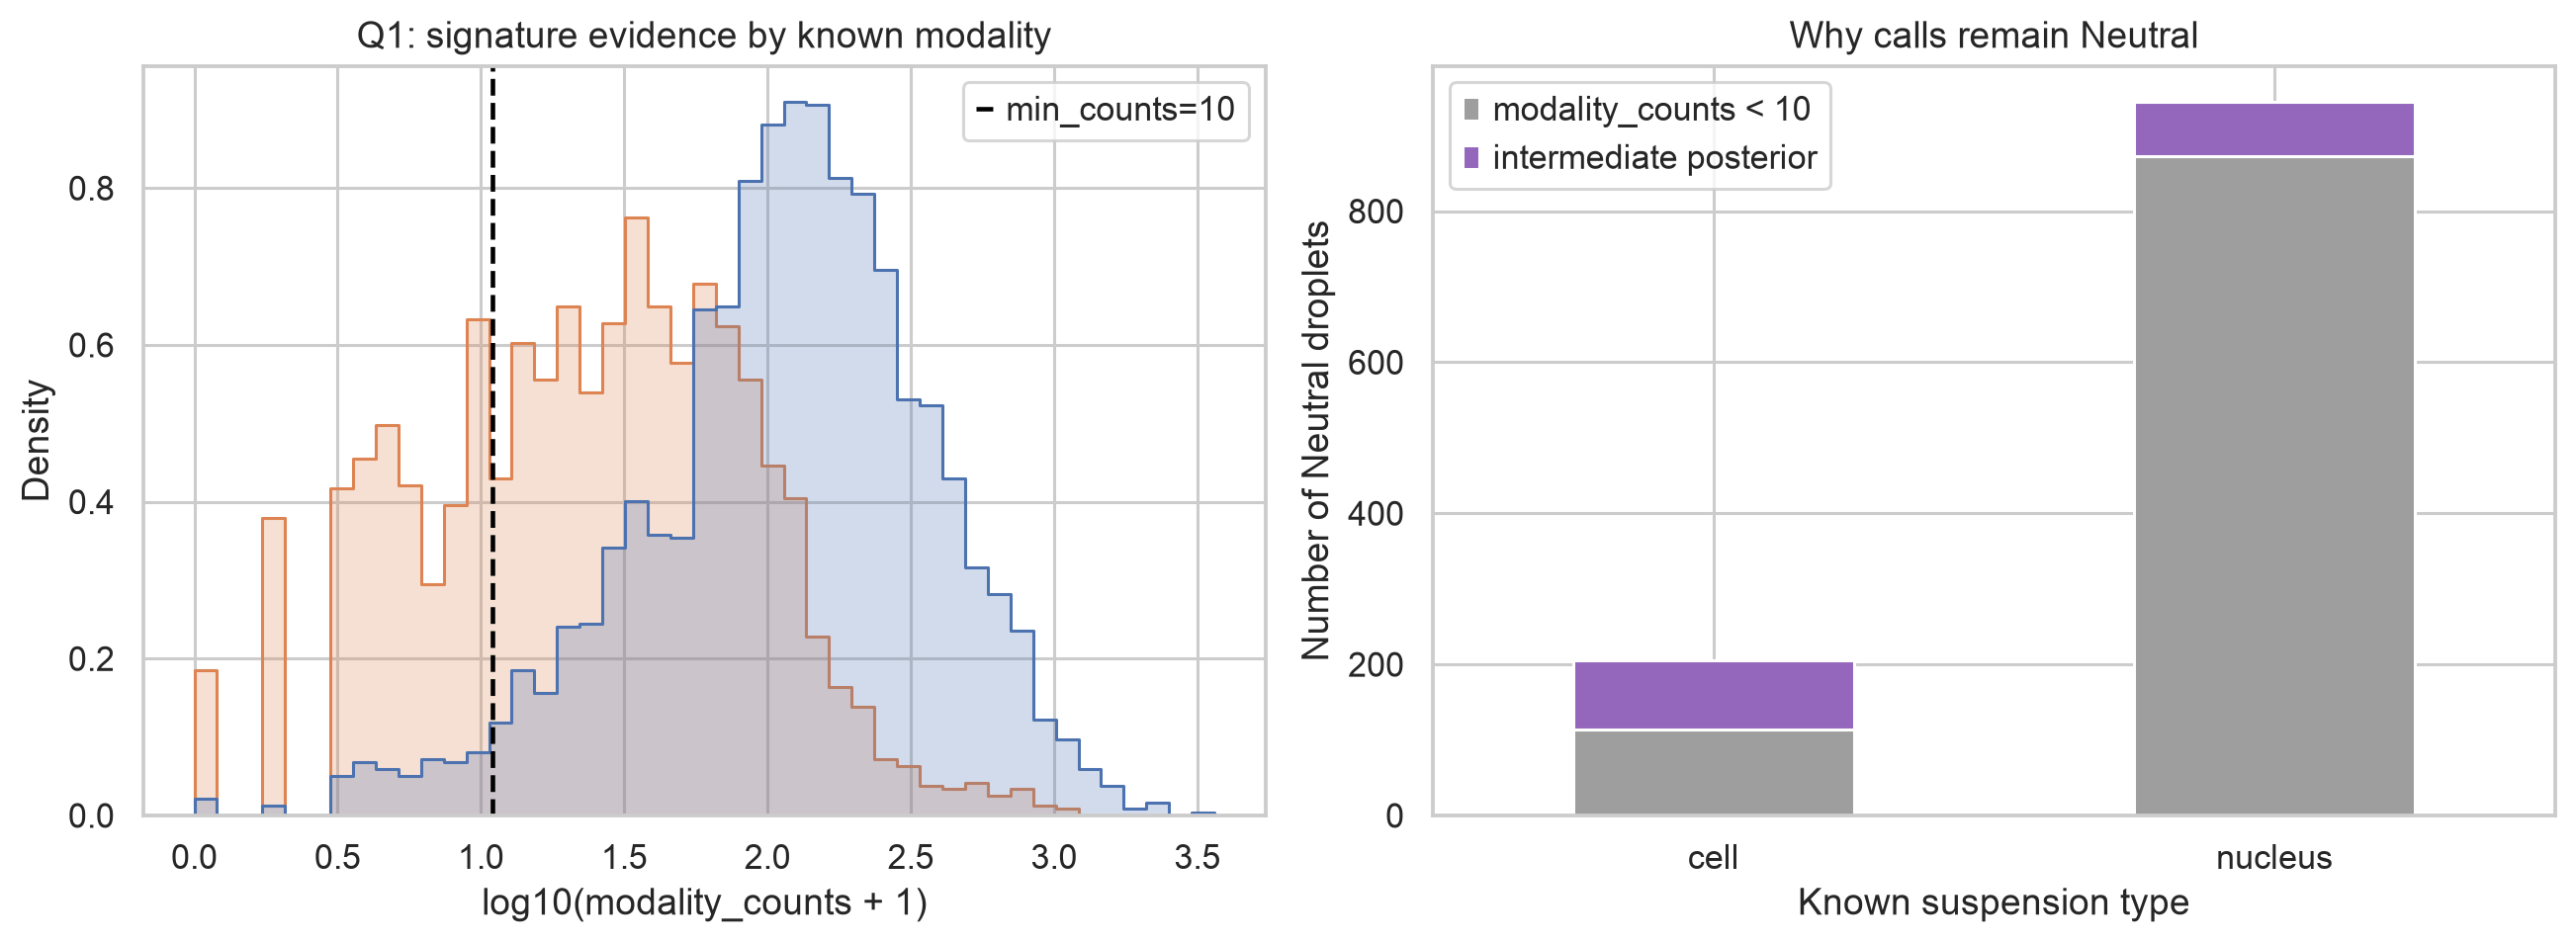

Saved figures/q1_modality_counts_and_neutral_sources_6k.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

q1_plot = q1.obs[["suspension_type", "modality_counts"]].copy()
q1_plot["log10_modality_counts_plus_1"] = np.log10(q1_plot["modality_counts"] + 1)
sns.histplot(
    data=q1_plot,
    x="log10_modality_counts_plus_1",
    hue="suspension_type",
    bins=45,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].axvline(
    np.log10(MIN_COUNTS + 1),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="min_counts=10",
)
axes[0].set_title("Q1: signature evidence by known modality")
axes[0].set_xlabel("log10(modality_counts + 1)")
axes[0].legend(title=None)

source_order = ["modality_counts < 10", "intermediate posterior"]
neutral_plot = q1_neutral_sources.reindex(columns=source_order, fill_value=0)
neutral_plot.plot(
    kind="bar",
    stacked=True,
    color=["#9e9e9e", "#9467bd"],
    ax=axes[1],
)
axes[1].set_title("Why calls remain Neutral")
axes[1].set_xlabel("Known suspension type")
axes[1].set_ylabel("Number of Neutral droplets")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title=None)

plt.tight_layout()
q1_evidence_figure = FIGURES_DIR / "q1_modality_counts_and_neutral_sources_6k.png"
fig.savefig(q1_evidence_figure, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved {q1_evidence_figure.relative_to(PROJECT_ROOT)}")

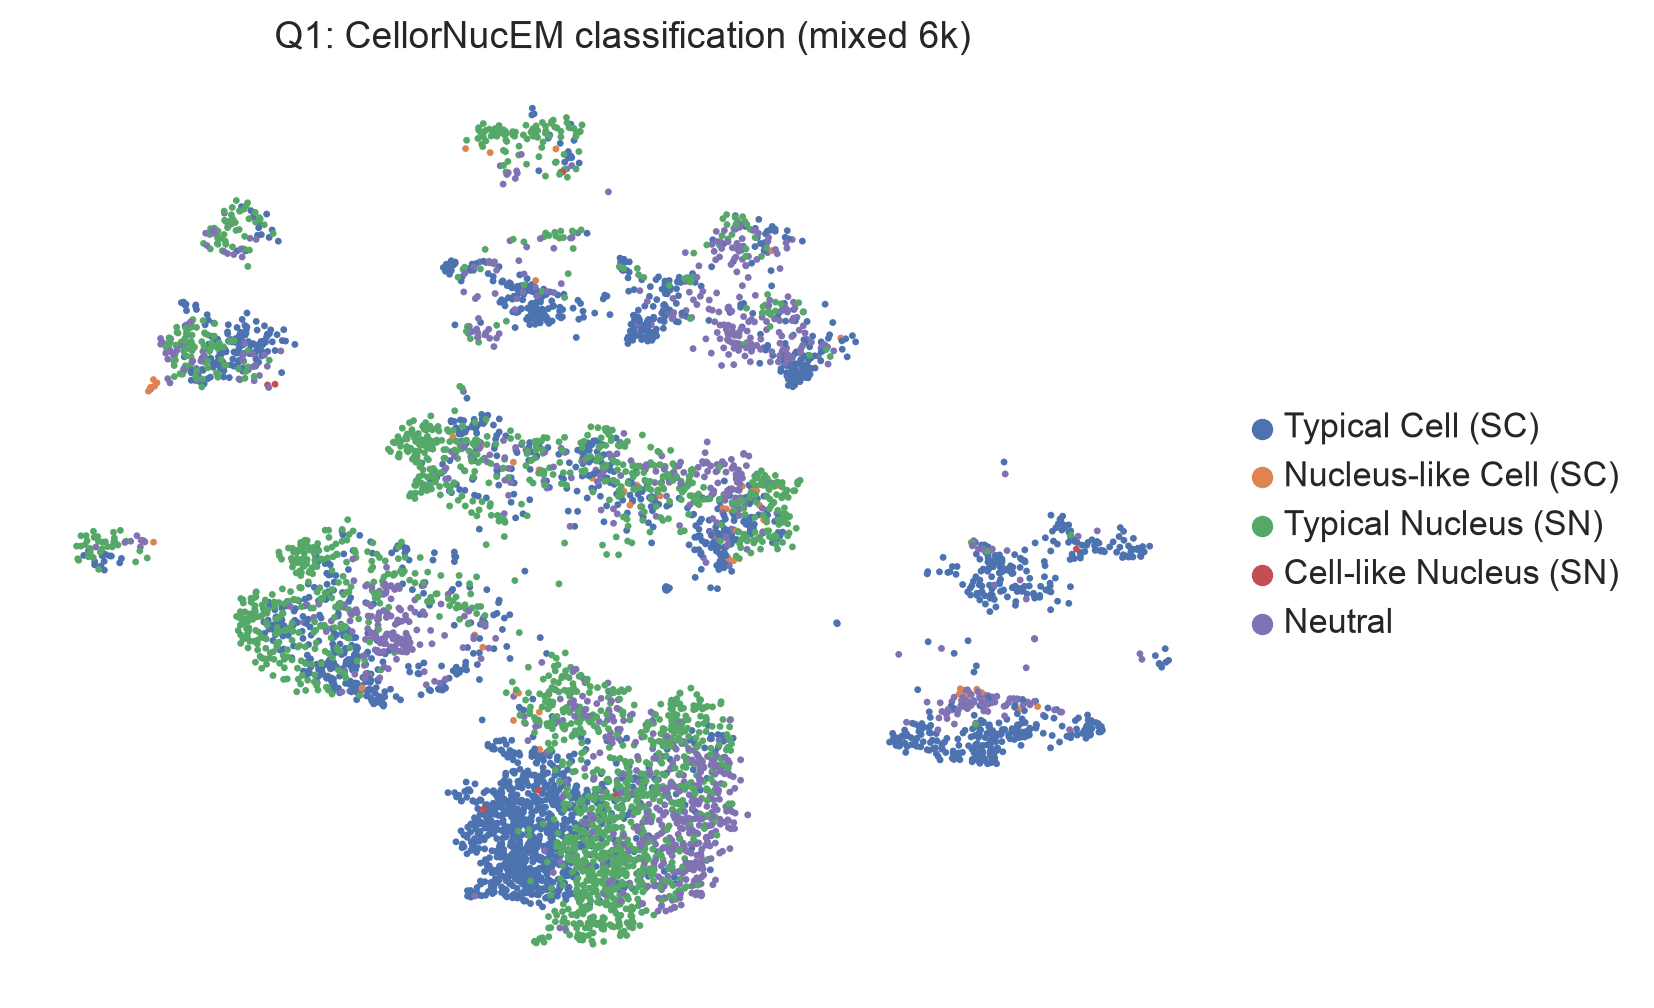

Saved figures/q1_classification_umap_6k.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sc.pl.umap(
    q1,
    color="modality_classification",
    ax=ax,
    show=False,
    frameon=False,
    title="Q1: CellorNucEM classification (mixed 6k)",
)
q1_umap_figure = FIGURES_DIR / "q1_classification_umap_6k.png"
fig.savefig(q1_umap_figure, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved {q1_umap_figure.relative_to(PROJECT_ROOT)}")

## Q1a answer

Because `assay_col` is supplied, the API does not literally label a known cell as `Typical Nucleus (SN)` or a known nucleus as `Typical Cell (SC)`. The corresponding discordant calls are named relative to the known assay:

- **59 of 3,000 known cells (1.97%)** are `Nucleus-like Cell (SC)`.
- **7 of 3,000 known nuclei (0.23%)** are `Cell-like Nucleus (SN)`.
- The combined confident discordance is **66 of 6,000 droplets (1.10%)**.

Among the 4,849 non-Neutral droplets, 4,783 agree with the known modality, giving **98.64% concordance among confidently classified droplets**. Concordance is 97.89% among non-Neutral cells and 99.66% among non-Neutral nuclei.

The fitted component means are approximately 0.961 for the cell-like component and 0.113 for the nucleus-like component, a separation of 0.848 on the sc-signature-fraction scale. The two-component BIC is lower than the one-component BIC by about 1,419. Together, the component separation and low confident discordance indicate that the provisional signature transfers well to this independent 6k sample when it has enough evidence. This conclusion should be qualified by the Neutral fraction, especially among nuclei.

## Q1b answer

`modality_counts` is the sum of counts over the available sc and sn signature genes, not total transcript counts. Its distribution is substantially lower for nuclei than cells: the mean is about **50.3 for nuclei versus 203.0 for cells**.

The 1,151 Neutral calls divide exactly into two code-defined sources:

- **Low signature evidence (`modality_counts < 10`):** 114 cells and 873 nuclei, or 987 total.
- **Intermediate posterior (`0.05 <= p_cell <= 0.95`) despite enough counts:** 92 cells and 72 nuclei, or 164 total.

Thus **85.8% of Neutral calls (987/1,151)** arise directly from failing `min_counts=10`. This disproportionately affects nuclei and explains why nuclei have many more Neutral calls. Likely contributors include lower RNA content in nuclei, sparse sampling/dropout among the short signature lists, cell-type-specific expression variation, and the fact that one provisional sn-signature gene (`AC098829.1`) is absent from dataset A. The remaining intermediate-posterior cases have enough signature counts but composition that is not decisively compatible with either fitted component; biological intermediacy, damaged cells, ambient RNA, mixed droplets, or imperfect signature transfer are plausible explanations, but the classifier alone cannot distinguish those causes.

# Q2. Run on the single-modality dataset B (sc only)

> Many real projects have only sc (or only sn) data. There, the classifier is used to find droplets of the “other kind” that slipped in - for example, droplets in an sc library whose cytoplasm lysed, leaving only the nucleus.
>
> **2a.** Load dataset B and run `CellorNucEM`. What fraction of droplets are Nucleus-like Cell (SC)?
>
> **2b.** Plot a histogram of `sc_frac`. Is it unimodal or bimodal?

## Q2 implementation

Dataset B lacks an assay-origin column, so a constant `modality='sc'` column is added exactly as in the official demo. This metadata affects final names and the single-modality fallback rule, not mixture fitting.

For Q2, the official demo's sc-only settings are made explicit: anchored initialization, `gamma_hi=0.95`, `gamma_lo=0.05`, `max_p_nuc=0.2`, and `min_p_cell=0.8`. Q3 below intentionally removes the two hard mean constraints when comparing initialization schemes.

In [10]:
q2_input = single_input.copy()
q2_input.obs["modality"] = "sc"

q2 = Scanpyplus.CellorNucEM(
    q2_input,
    sc_genes,
    sn_genes,
    assay_col="modality",
    layer="counts",
    min_counts=MIN_COUNTS,
    copy=True,
    gamma_hi=GAMMA_HI,
    gamma_lo=GAMMA_LO,
    init="anchored",
    max_p_nuc=0.2,
    min_p_cell=0.8,
    print_mode=False,
)

In [11]:
q2_counts = q2.obs["modality_classification"].value_counts().rename("count")
q2_percent = q2_counts.div(q2.n_obs).mul(100).rename("percent")
q2_summary = pd.concat([q2_counts, q2_percent], axis=1)
q2_fit = global_fit_summary(q2).rename("value").to_frame()

print("Classification summary:")
display(q2_summary)
print("Global beta-binomial fit:")
display(q2_fit)
print("sc_frac summary (NaN occurs when modality_counts=0):")
display(q2.obs["sc_frac"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

q2_enough_counts = q2.obs["modality_counts"].ge(MIN_COUNTS)
q2_confident_cell = q2_enough_counts & q2.obs["p_cell"].gt(GAMMA_HI)
q2_confident_nucleus = q2_enough_counts & q2.obs["p_cell"].lt(GAMMA_LO)
q2_undecided_before_fallback = ~(q2_confident_cell | q2_confident_nucleus)
print("Undecided before single-mode fallback:", int(q2_undecided_before_fallback.sum()))

q2_summary.to_csv(RESULTS_DIR / "q2" / "classification_summary_6k.csv")
q2_fit.to_csv(RESULTS_DIR / "q2" / "global_fit_6k.csv")

Classification summary:


,count,percent
modality_classification,,
Typical Cell (SC),5820,97.0
Nucleus-like Cell (SC),180,3.0


Global beta-binomial fit:


,value
p_cell_component,0.909144
p_nucleus_component,0.200000
cell_concentration,4.218520
nucleus_concentration,1.809886
lam_cell,0.935251
component_separation,0.709144
bic_1,31605.320513
bic_2,30942.811705
delta_bic_bic1_minus_bic2,662.508808
loglik,-15449.972864


sc_frac summary (NaN occurs when modality_counts=0):


count    5973.000000
mean        0.834887
std         0.264896
min         0.000000
1%          0.000000
5%          0.076923
10%         0.437500
25%         0.800000
50%         0.957895
75%         1.000000
90%         1.000000
95%         1.000000
99%         1.000000
max         1.000000
Name: sc_frac, dtype: float64

Undecided before single-mode fallback: 1220


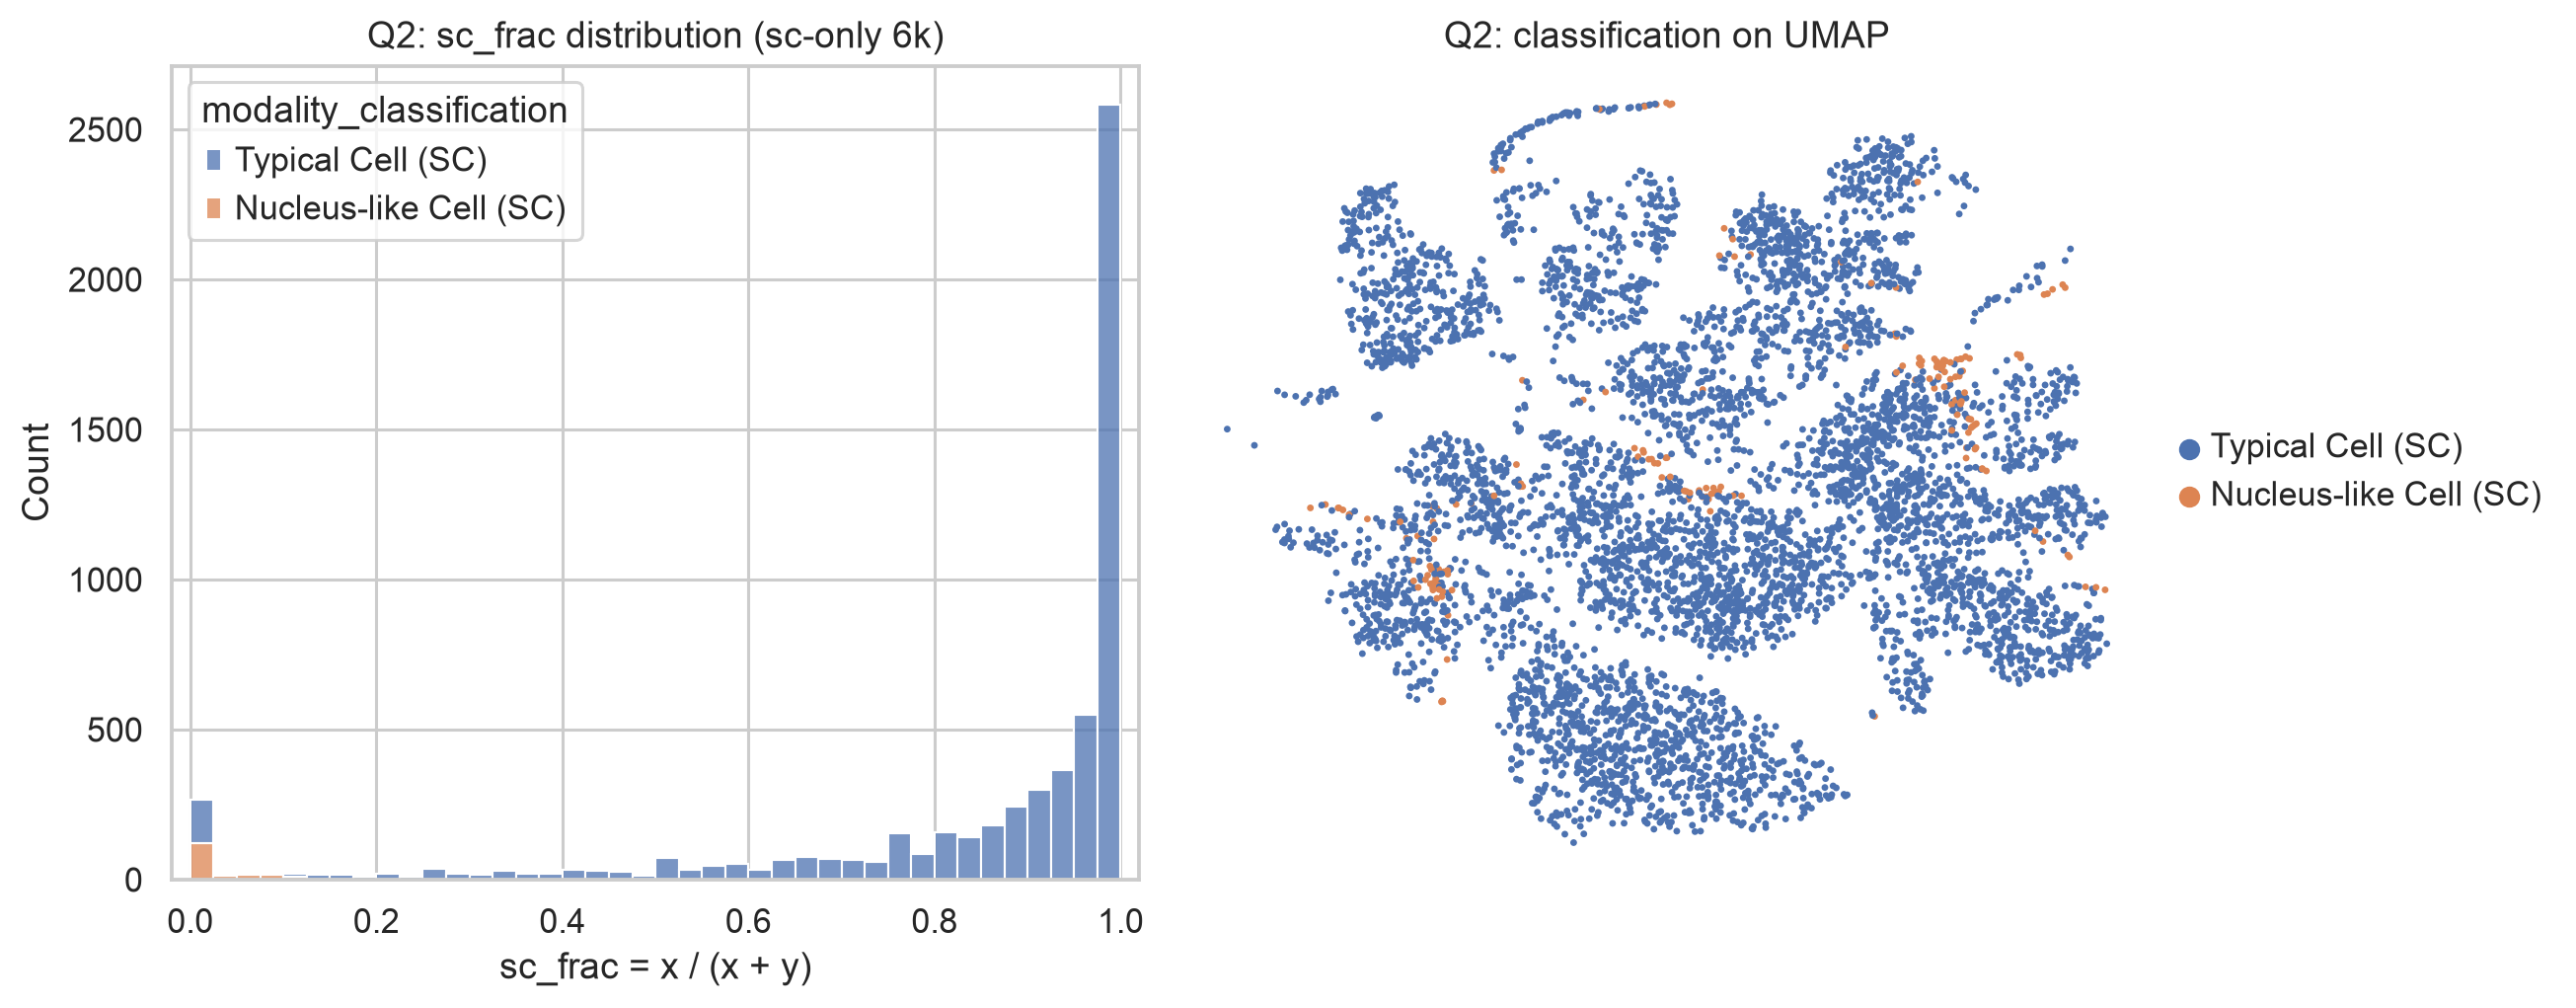

Saved figures/q2_sc_frac_and_classification_6k.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

q2_plot = q2.obs[["sc_frac", "modality_classification"]].copy()
sns.histplot(
    data=q2_plot,
    x="sc_frac",
    hue="modality_classification",
    bins=np.linspace(0, 1, 41),
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Q2: sc_frac distribution (sc-only 6k)")
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_xlabel("sc_frac = x / (x + y)")

sc.pl.umap(
    q2,
    color="modality_classification",
    ax=axes[1],
    show=False,
    frameon=False,
    title="Q2: classification on UMAP",
)

plt.tight_layout()
q2_figure = FIGURES_DIR / "q2_sc_frac_and_classification_6k.png"
fig.savefig(q2_figure, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved {q2_figure.relative_to(PROJECT_ROOT)}")

## Q2 answers

### Q2a

The constrained anchored fit calls **180 of 6,000 droplets** `Nucleus-like Cell (SC)`, a fraction of **3.00%**. The other 5,820 droplets are labeled `Typical Cell (SC)`.

In single-sc mode, the typical class includes both confidently cell-like droplets and 1,220 undecided/low-evidence droplets reassigned by the function's single-modality rule. The 3.00% anomalous fraction is therefore the fraction meeting the stricter conditions `modality_counts >= 10` and `p_cell < 0.05`.

### Q2b

The histogram is **bimodal in a practical, strongly imbalanced sense**: there is a dominant high-`sc_frac` mode concentrated near 0.95-1.00 and a much smaller low-`sc_frac`/zero-enriched mode, with a broad bridge between them. It is not a clean pair of symmetric peaks, so “dominant cell-like mode plus a small diffuse nucleus-like mode” is more precise than simply saying two equal modes. There are 27 droplets with `modality_counts=0`; their `sc_frac` is undefined and they do not appear in the histogram.

# Q3. What do the anchors (constraints) do in the single-modality case?

> `CellorNucEM` has an “anchor” related mechanism:
>
> **3a.** On dataset B, run (i) default parameters; `init='anchored'`, (ii) `init='split'`. Compare the two component means p between the two fits. Are the differences large? If yes, what could be the reasons?
>
> **3b.** Switch to dataset A: take only droplets with `suspension_type == 'cell'` and compare (i) and (ii) in the same way; then do the same with nucleus only.

## Q3 implementation

To isolate initialization, these fits use the `CellorNucEM` defaults, including `min_counts=10`, `gamma_hi=0.9`, `gamma_lo=0.1`, `anchor_lo=0.3`, `anchor_hi=0.7`, and no hard mean constraints. Only `init` changes.

`layer='counts'` selects the required data representation; `copy=True` prevents mutation; `print_mode=False` suppresses repeated display. None of those three choices changes the global mixture objective.

In [13]:
def run_q3_pair(adata, case_name):
    rows = []
    distribution = None
    for init in ("anchored", "split"):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            fitted = Scanpyplus.CellorNucEM(
                adata,
                sc_genes,
                sn_genes,
                layer="counts",
                init=init,
                copy=True,
                print_mode=False,
            )
        summary = global_fit_summary(fitted)
        rows.append(
            {
                "case": case_name,
                "init": init,
                **summary.to_dict(),
                "warnings": " | ".join(str(w.message) for w in caught),
            }
        )
        if init == "anchored":
            distribution = fitted.obs["sc_frac"].copy()
    return rows, distribution


q3_cases = {
    "B: sc-only": single_input,
    "A: cells only": mixed_input[mixed_input.obs["suspension_type"] == "cell"].copy(),
    "A: nuclei only": mixed_input[mixed_input.obs["suspension_type"] == "nucleus"].copy(),
}

q3_rows = []
q3_distributions = {}
for case_name, case_data in q3_cases.items():
    rows, distribution = run_q3_pair(case_data, case_name)
    q3_rows.extend(rows)
    q3_distributions[case_name] = distribution

q3_results = pd.DataFrame(q3_rows).set_index(["case", "init"])
q3_results

p_cell_component  p_nucleus_component  \
case           init                                              
B: sc-only     anchored          0.913259             0.334713   
               split             0.915145             0.572044   
A: cells only  anchored          0.975237             0.656356   
               split             0.976480             0.840313   
A: nuclei only anchored          0.362833             0.079727   
               split             0.169949             0.068678   

                         cell_concentration  nucleus_concentration  lam_cell  \
case           init                                                            
B: sc-only     anchored            4.448869               1.064618  0.914118   
               split               4.734540               0.636027  0.848644   
A: cells only  anchored           12.637726               2.131612  0.902609   
               split              14.304577               1.459660  0.763417   
A: nuclei only anchored            8.222066              14.083208  0.100589   
               split               4.594285              19.771058  0.390075   

                         component_separation         bic_1         bic_2  \
case           init                                                         
B: sc-only     anchored              0.578546  31605.320513  30939.863846   
               split                 0.343101  31605.320513  30939.374435   
A: cells only  anchored              0.318880  14888.901227  14642.474573   
               split                 0.136166  14888.901227  14641.019138   
A: nuclei only anchored              0.283105  11498.527533  11445.196538   
               split                 0.101271  11498.527533  11443.483949   

                         delta_bic_bic1_minus_bic2        loglik warnings  
case           init                                                        
B: sc-only     anchored                 665.456667 -15448.498934           
               split                    665.946078 -15448.254229           
A: cells only  anchored                 246.426655  -7301.318219           
               split                    247.882090  -7300.590502           
A: nuclei only anchored                  53.330995  -5703.442100           
               split                     55.043584  -5702.585805

In [14]:
q3_means = q3_results[
    [
        "p_cell_component",
        "p_nucleus_component",
        "lam_cell",
        "component_separation",
        "bic_1",
        "bic_2",
        "delta_bic_bic1_minus_bic2",
    ]
].copy()

display(q3_means)

q3_differences = []
for case_name in q3_cases:
    anchored = q3_results.loc[(case_name, "anchored")]
    split = q3_results.loc[(case_name, "split")]
    q3_differences.append(
        {
            "case": case_name,
            "abs_difference_cell_mean": abs(
                anchored["p_cell_component"] - split["p_cell_component"]
            ),
            "abs_difference_nucleus_mean": abs(
                anchored["p_nucleus_component"] - split["p_nucleus_component"]
            ),
            "bic2_split_minus_anchored": split["bic_2"] - anchored["bic_2"],
        }
    )
q3_differences = pd.DataFrame(q3_differences).set_index("case")
print("Absolute differences between initializations:")
display(q3_differences)

q3_means.to_csv(RESULTS_DIR / "q3" / "initialization_fits_6k.csv")
q3_differences.to_csv(RESULTS_DIR / "q3" / "initialization_differences_6k.csv")

p_cell_component  p_nucleus_component  lam_cell  \
case           init                                                        
B: sc-only     anchored          0.913259             0.334713  0.914118   
               split             0.915145             0.572044  0.848644   
A: cells only  anchored          0.975237             0.656356  0.902609   
               split             0.976480             0.840313  0.763417   
A: nuclei only anchored          0.362833             0.079727  0.100589   
               split             0.169949             0.068678  0.390075   

                         component_separation         bic_1         bic_2  \
case           init                                                         
B: sc-only     anchored              0.578546  31605.320513  30939.863846   
               split                 0.343101  31605.320513  30939.374435   
A: cells only  anchored              0.318880  14888.901227  14642.474573   
               split                 0.136166  14888.901227  14641.019138   
A: nuclei only anchored              0.283105  11498.527533  11445.196538   
               split                 0.101271  11498.527533  11443.483949   

                         delta_bic_bic1_minus_bic2  
case           init                                 
B: sc-only     anchored                 665.456667  
               split                    665.946078  
A: cells only  anchored                 246.426655  
               split                    247.882090  
A: nuclei only anchored                  53.330995  
               split                     55.043584

Absolute differences between initializations:


,abs_difference_cell_mean,abs_difference_nucleus_mean,bic2_split_minus_anchored
case,,,
B: sc-only,0.001886,0.237331,-0.489410
A: cells only,0.001243,0.183957,-1.455435
A: nuclei only,0.192884,0.011050,-1.712589


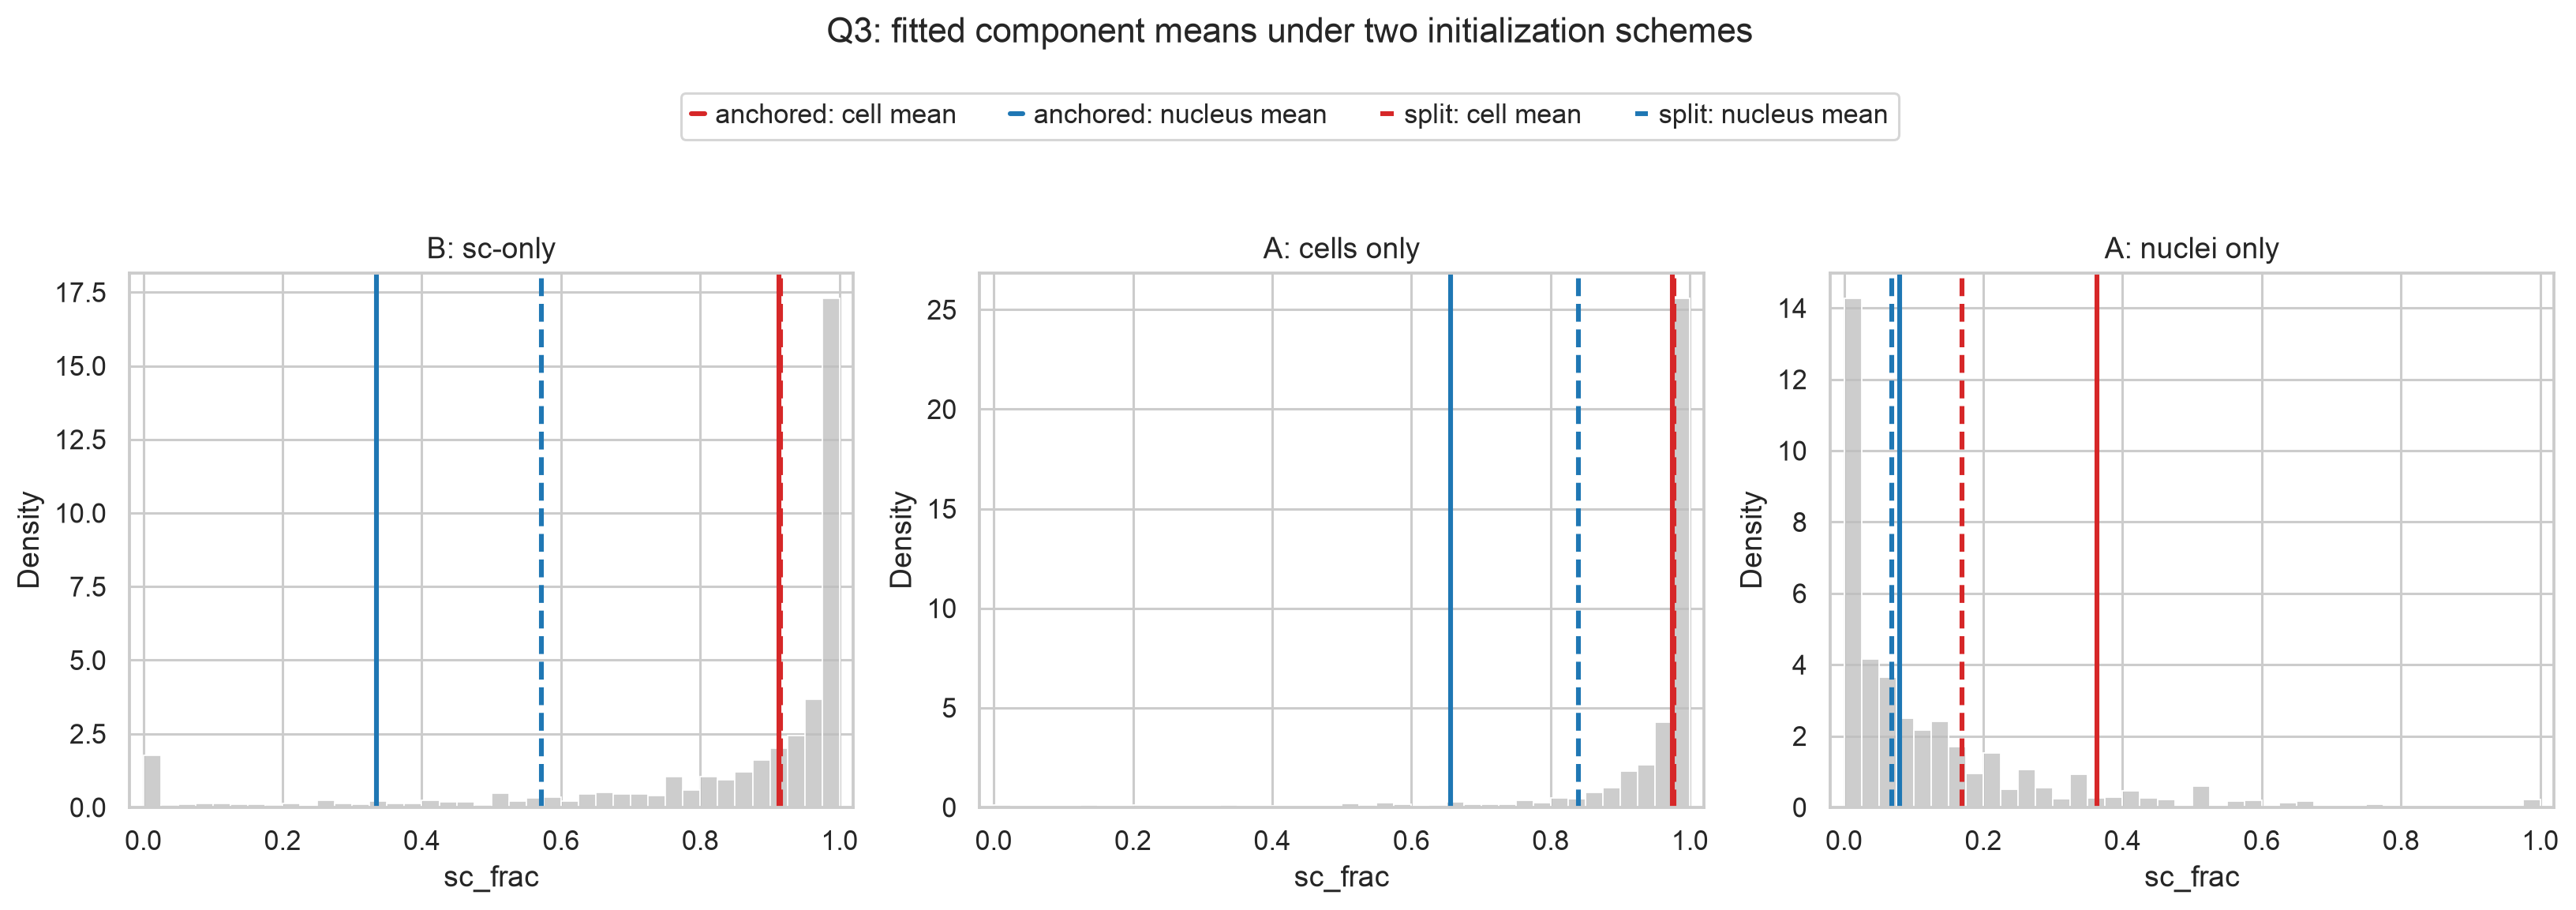

Saved figures/q3_initialization_component_means_6k.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
line_specs = {
    ("anchored", "cell"): ("#d62728", "-"),
    ("anchored", "nucleus"): ("#1f77b4", "-"),
    ("split", "cell"): ("#d62728", "--"),
    ("split", "nucleus"): ("#1f77b4", "--"),
}

for ax, case_name in zip(axes, q3_cases):
    sns.histplot(
        q3_distributions[case_name].dropna(),
        bins=np.linspace(0, 1, 41),
        stat="density",
        color="#bdbdbd",
        ax=ax,
    )
    for init in ("anchored", "split"):
        row = q3_results.loc[(case_name, init)]
        for component, column in (
            ("cell", "p_cell_component"),
            ("nucleus", "p_nucleus_component"),
        ):
            color, style = line_specs[(init, component)]
            ax.axvline(row[column], color=color, linestyle=style, linewidth=2)
    ax.set_title(case_name)
    ax.set_xlabel("sc_frac")
    ax.set_xlim(-0.02, 1.02)
axes[0].set_ylabel("Density")

handles = [
    Line2D([0], [0], color="#d62728", linestyle="-", linewidth=2, label="anchored: cell mean"),
    Line2D([0], [0], color="#1f77b4", linestyle="-", linewidth=2, label="anchored: nucleus mean"),
    Line2D([0], [0], color="#d62728", linestyle="--", linewidth=2, label="split: cell mean"),
    Line2D([0], [0], color="#1f77b4", linestyle="--", linewidth=2, label="split: nucleus mean"),
]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=4)
fig.suptitle("Q3: fitted component means under two initialization schemes", y=1.16)
plt.tight_layout()
q3_figure = FIGURES_DIR / "q3_initialization_component_means_6k.png"
fig.savefig(q3_figure, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved {q3_figure.relative_to(PROJECT_ROOT)}")

## Q3a answer - dataset B

For the sc-only dataset B:

| Initialization | Cell-component mean | Nucleus-component mean |
|---|---:|---:|
| anchored | 0.9133 | 0.3347 |
| split | 0.9151 | 0.5720 |

The cell-component means differ by only **0.0019**, but the nucleus-component means differ by **0.2373**, which is large on a 0-1 fraction scale.

The dominant high-`sc_frac` component is well supported and stable. The putative nucleus component is a minority component in an sc-only dataset and is much less identifiable. `split` initializes by cutting at the evidence-weighted mean, which can divide the broad dominant population; `anchored` starts the low component from the low tail. Because mixture likelihoods have local optima, those starting points can lead to different decompositions. Their two-component BIC values differ by less than 0.5, showing that nearly equal objective values can correspond to substantially different minority-component means.

## Q3b answer - cells-only and nuclei-only subsets of dataset A

For **known cells only**:

| Initialization | Cell-component mean | Nucleus-component mean |
|---|---:|---:|
| anchored | 0.9752 | 0.6564 |
| split | 0.9765 | 0.8403 |

The dominant cell mean changes by only **0.0012**, whereas the putative nucleus mean changes by **0.1840**.

For **known nuclei only**:

| Initialization | Cell-component mean | Nucleus-component mean |
|---|---:|---:|
| anchored | 0.3628 | 0.0797 |
| split | 0.1699 | 0.0687 |

Here the dominant nucleus mean changes by only **0.0110**, whereas the putative cell mean changes by **0.1929**.

The same pattern appears in both one-modality subsets: the component matching the observed majority modality is stable, while the absent or rare opposite component is sensitive to initialization. BIC2 differs by only about 1.5-1.7 between initializations in these subsets, again indicating similar fit quality but different parameter decompositions.

Therefore the anchors mainly stabilize the **starting interpretation** of the minority component. They do not guarantee that the final component mean stays near 0 or 1. `anchor_lo` and `anchor_hi` select initialization tails; only `max_p_nuc` and `min_p_cell` impose hard mean bounds. In single-modality data, fitted minority-component parameters should be interpreted cautiously and checked across initialization, BIC, prevalence, and biological context.

# Reproducibility and consistency checks

In [16]:
required_obs = {
    "modality_counts",
    "sc_frac",
    "p_cell",
    "modality_fit",
    "modality_classification",
}
assert required_obs.issubset(q1.obs.columns)
assert required_obs.issubset(q2.obs.columns)
assert q1_counts.to_numpy().sum() == mixed_input.n_obs == 6000
assert q2_counts.sum() == single_input.n_obs == 6000
assert q1_neutral_sources.to_numpy().sum() == neutral.sum()
assert set(q3_results.index.get_level_values("case")) == set(q3_cases)
assert set(q3_results.index.get_level_values("init")) == {"anchored", "split"}
assert not q3_results[["p_cell_component", "p_nucleus_component"]].isna().any().any()
assert all(
    q3_results["p_cell_component"] > q3_results["p_nucleus_component"]
)

expected_figures = [q1_evidence_figure, q1_umap_figure, q2_figure, q3_figure]
assert all(path.exists() and path.stat().st_size > 0 for path in expected_figures)

print("All consistency checks passed.")
print("Figures:")
for path in expected_figures:
    print(f"- {path.relative_to(PROJECT_ROOT)}")
print("Result tables:")
for path in sorted(RESULTS_DIR.glob("q*/*_6k.csv")):
    print(f"- {path.relative_to(PROJECT_ROOT)}")

All consistency checks passed.
Figures:
- figures/q1_modality_counts_and_neutral_sources_6k.png
- figures/q1_classification_umap_6k.png
- figures/q2_sc_frac_and_classification_6k.png
- figures/q3_initialization_component_means_6k.png
Result tables:
- results/q1/classification_counts_6k.csv
- results/q1/classification_percent_within_modality_6k.csv
- results/q1/global_fit_6k.csv
- results/q1/modality_counts_summary_6k.csv
- results/q1/neutral_sources_6k.csv
- results/q2/classification_summary_6k.csv
- results/q2/global_fit_6k.csv
- results/q3/initialization_differences_6k.csv
- results/q3/initialization_fits_6k.csv


## Final interpretation

On these 6k files, the signatures clearly separate the mixed dataset when sufficient signature counts are present, while most mixed-data uncertainty is caused by the `min_counts=10` evidence gate. The sc-only analysis finds a small low-`sc_frac` component under the official constrained settings. The Q3 experiments show why initialization matters: in one-modality data, the well-supported majority component is stable, but the inferred opposite/minority component can move substantially with the initialization scheme.

These results are specific to the supplied 6k subsamples, the current provisional `hcka_v1` signatures, and the explicitly recorded parameters above.

# Bonus - Cell Identity and Classifier Scores

The datasets already contain author-provided biological labels, so no new clustering or annotation is needed. Clustering identifies expression-similar groups; it does not by itself assign biological identity.

Dataset B is analyzed by `reannotated_celltype`. Dataset A is analyzed by `broad_cell_type` separately within known cells and nuclei, because pooling the two suspension types would allow the cell-versus-nucleus main effect to dominate the cell-type comparison. These are descriptive association analyses, not tests of biological mechanism.

In [17]:
bonus_inventory = pd.DataFrame(
    [
        ["A: mixed", "broad_cell_type", q1.obs["broad_cell_type"].nunique()],
        ["A: mixed", "cell_type", q1.obs["cell_type"].nunique()],
        ["B: sc-only", "reannotated_celltype", q2.obs["reannotated_celltype"].nunique()],
        ["B: sc-only", "Predicted", q2.obs["Predicted"].nunique()],
        ["B: sc-only", "leiden (cluster, not annotation)", q2.obs["leiden"].nunique()],
    ],
    columns=["dataset", "column", "number_of_labels"],
)
bonus_inventory

,dataset,column,number_of_labels
0,A: mixed,broad_cell_type,12
1,A: mixed,cell_type,35
2,B: sc-only,reannotated_celltype,85
3,B: sc-only,Predicted,65
4,B: sc-only,"leiden (cluster, not annotation)",41


## Dataset B: which cell identities receive Nucleus-like calls?

Dataset B is the cleaner primary analysis because every library is nominally sc. For each author-provided refined identity, the table reports the hard-call rate, continuous posterior, and signature evidence. Groups with fewer than 20 droplets are omitted from the ranked display to avoid emphasizing unstable small-sample percentages.

In [18]:
bonus_b = q2.obs.copy()
bonus_b["cell_identity"] = bonus_b["reannotated_celltype"].astype("string").fillna("Unannotated")
bonus_b["nucleus_like"] = bonus_b["modality_classification"].astype(str).eq("Nucleus-like Cell (SC)")
bonus_b["below_min_counts"] = bonus_b["modality_counts"].lt(10)

bonus_b_summary = (
    bonus_b.groupby("cell_identity", observed=True)
    .agg(
        n=("p_cell", "size"),
        nucleus_like_n=("nucleus_like", "sum"),
        median_p_cell=("p_cell", "median"),
        median_modality_counts=("modality_counts", "median"),
        below_min_counts_rate=("below_min_counts", "mean"),
        n_batches=("batch", "nunique"),
    )
)
bonus_b_summary["nucleus_like_rate"] = bonus_b_summary["nucleus_like_n"] / bonus_b_summary["n"]
bonus_b_ranked = bonus_b_summary.query("n >= 20").sort_values(
    ["nucleus_like_rate", "n"], ascending=[False, False]
)

print(f"Overall Nucleus-like rate: {bonus_b['nucleus_like'].mean():.2%}")
display(
    bonus_b_ranked[
        ["n", "nucleus_like_n", "nucleus_like_rate", "median_p_cell",
         "median_modality_counts", "below_min_counts_rate", "n_batches"]
    ].head(15).style.format(
        {
            "nucleus_like_rate": "{:.1%}",
            "median_p_cell": "{:.3f}",
            "median_modality_counts": "{:.1f}",
            "below_min_counts_rate": "{:.1%}",
        }
    )
)

Overall Nucleus-like rate: 3.00%


,n,nucleus_like_n,nucleus_like_rate,median_p_cell,median_modality_counts,below_min_counts_rate,n_batches
cell_identity,,,,,,,
CCD-PC|CNT doub,25,15,60.0%,0.007,22.0,12.0%,11
CCD-PC,69,35,50.7%,0.024,16.0,27.5%,18
PCDH15+ aPT,25,5,20.0%,0.983,128.0,0.0%,16
aPT,177,26,14.7%,0.983,76.0,4.0%,41
PEC,63,7,11.1%,0.993,59.0,7.9%,29
DTL2,74,8,10.8%,0.858,38.0,12.2%,14
Neuron,56,6,10.7%,0.418,6.5,73.2%,9
LowQ neuron,22,2,9.1%,0.919,3.0,68.2%,8
aTAL,150,9,6.0%,0.998,46.5,13.3%,16


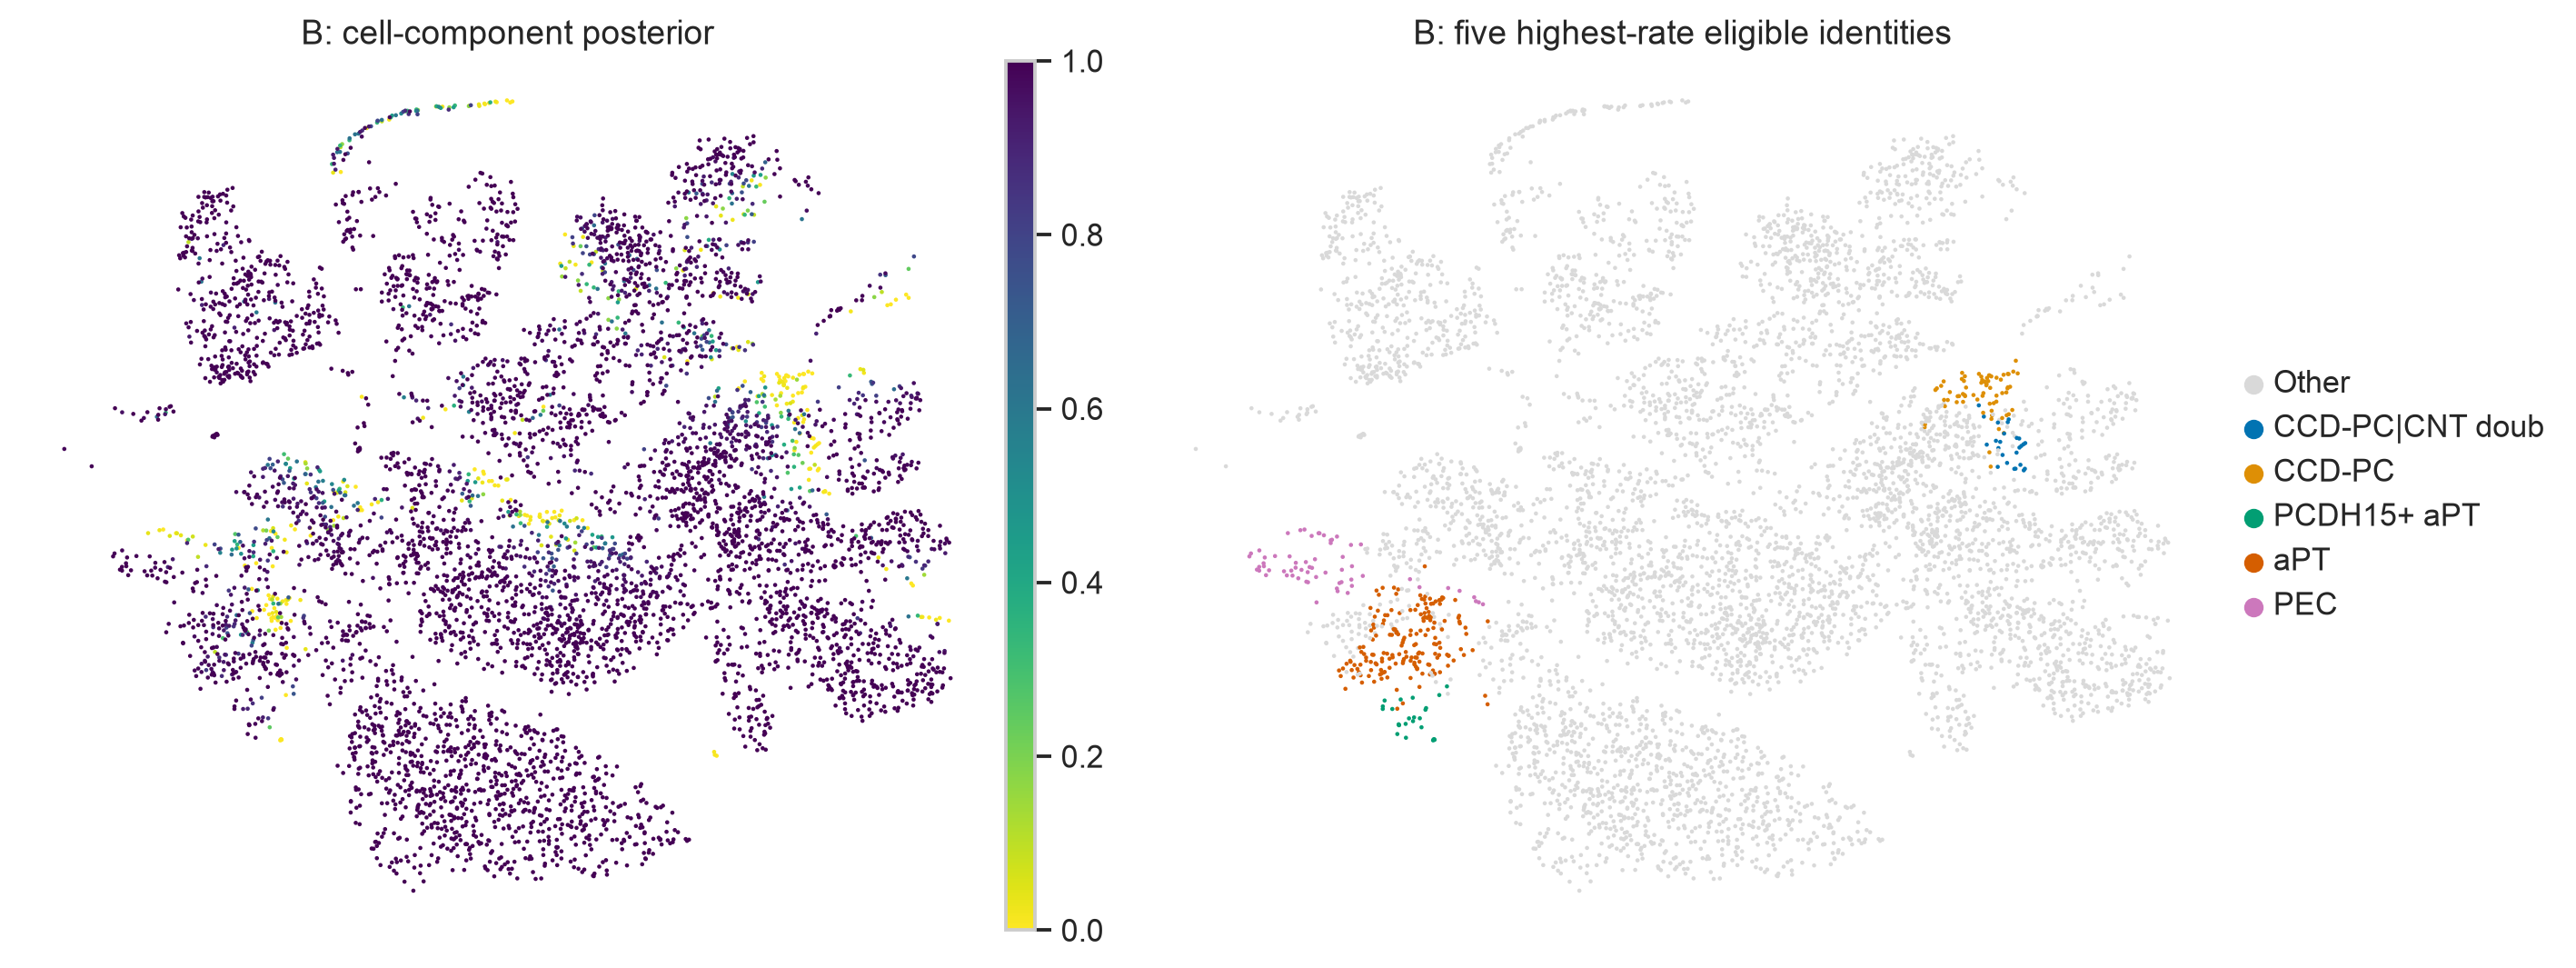

In [19]:
# UMAP is a localization check, not statistical evidence.
top_b_types = bonus_b_ranked.head(5).index.tolist()
q2.obs["bonus_top_identity"] = np.where(
    q2.obs["reannotated_celltype"].astype("string").isin(top_b_types),
    q2.obs["reannotated_celltype"].astype("string"),
    "Other",
)
q2.obs["bonus_top_identity"] = pd.Categorical(
    q2.obs["bonus_top_identity"], categories=["Other", *top_b_types]
)

top_colors = sns.color_palette("colorblind", len(top_b_types)).as_hex()
identity_palette = {"Other": "#d9d9d9", **dict(zip(top_b_types, top_colors))}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(
    q2, color="p_cell", cmap="viridis_r", vmin=0, vmax=1,
    size=9, ax=axes[0], show=False, frameon=False,
    title="B: cell-component posterior",
)
sc.pl.umap(
    q2, color="bonus_top_identity", palette=identity_palette,
    size=9, ax=axes[1], show=False, frameon=False,
    title="B: five highest-rate eligible identities",
)
plt.tight_layout()
plt.show()

The Nucleus-like calls are not distributed uniformly across the supplied identities. The highest eligible rates occur in `CCD-PC|CNT doub` (15/25, 60.0%) and `CCD-PC` (35/69, 50.7%), both of which have relatively modest signature evidence; the explicit doublet label also suggests a mixed-profile explanation for the first group. `aPT` is also elevated (26/177, 14.7%) but has a median `modality_counts` of 76 and only 4.0% below the count gate, showing that the pattern is not explained by low signature counts alone.

The UMAP only shows where low posterior values and the highest-rate identities lie in the existing expression embedding. Their localization is useful for follow-up, but it does not prove that the droplets are physical nuclei or establish a causal cell-type effect.

## Dataset A: Neutral calls within known cells and nuclei

Dataset A is stratified by `suspension_type` before comparing broad identities. The table includes `modality_counts` and the below-threshold rate so that a Neutral-heavy identity can be checked against the Q1b evidence gate.

In [20]:
bonus_a = q1.obs.copy()
bonus_a["cell_identity"] = bonus_a["broad_cell_type"].astype("string").fillna("Unannotated")
bonus_a["source"] = bonus_a["suspension_type"].astype("string")
bonus_a["neutral"] = bonus_a["modality_classification"].astype(str).eq("Neutral")
bonus_a["below_min_counts"] = bonus_a["modality_counts"].lt(10)
bonus_a["discordant"] = np.where(
    bonus_a["source"].eq("cell"),
    bonus_a["modality_classification"].astype(str).eq("Nucleus-like Cell (SC)"),
    bonus_a["modality_classification"].astype(str).eq("Cell-like Nucleus (SN)"),
)

bonus_a_summary = (
    bonus_a.groupby(["source", "cell_identity"], observed=True)
    .agg(
        n=("p_cell", "size"),
        neutral_n=("neutral", "sum"),
        discordant_n=("discordant", "sum"),
        median_modality_counts=("modality_counts", "median"),
        below_min_counts_rate=("below_min_counts", "mean"),
    )
    .reset_index()
)
bonus_a_summary["neutral_rate"] = bonus_a_summary["neutral_n"] / bonus_a_summary["n"]
bonus_a_summary["discordant_rate"] = bonus_a_summary["discordant_n"] / bonus_a_summary["n"]

bonus_a_ranked = (
    bonus_a_summary.query("n >= 20")
    .sort_values(["source", "neutral_rate", "n"], ascending=[True, False, False])
)
bonus_a_display = bonus_a_ranked.groupby("source", observed=True).head(6)

display(
    bonus_a_display[
        ["source", "cell_identity", "n", "neutral_n", "neutral_rate",
         "discordant_rate", "median_modality_counts", "below_min_counts_rate"]
    ].style.format(
        {
            "neutral_rate": "{:.1%}",
            "discordant_rate": "{:.1%}",
            "median_modality_counts": "{:.1f}",
            "below_min_counts_rate": "{:.1%}",
        }
    )
)

,source,cell_identity,n,neutral_n,neutral_rate,discordant_rate,median_modality_counts,below_min_counts_rate
7,cell,Podocyte,23,4,17.4%,13.0%,57.0,4.3%
2,cell,Endothelial Cell,329,56,17.0%,0.6%,46.0,12.8%
8,cell,Principal Cell,179,27,15.1%,8.4%,86.0,1.1%
4,cell,Immune Cell,532,61,11.5%,1.5%,91.0,10.5%
0,cell,Connecting Tubule Cell,138,12,8.7%,4.3%,140.5,0.0%
10,cell,Thick Ascending Limb Cell,369,21,5.7%,1.1%,141.0,1.6%
16,nucleus,Immune Cell,36,31,86.1%,2.8%,4.0,80.6%
15,nucleus,Fibroblast,22,16,72.7%,0.0%,6.0,68.2%
14,nucleus,Endothelial Cell,187,133,71.1%,0.0%,6.0,67.4%
23,nucleus,Vascular Smooth Muscle Cell / Pericyte,45,21,46.7%,0.0%,11.0,44.4%


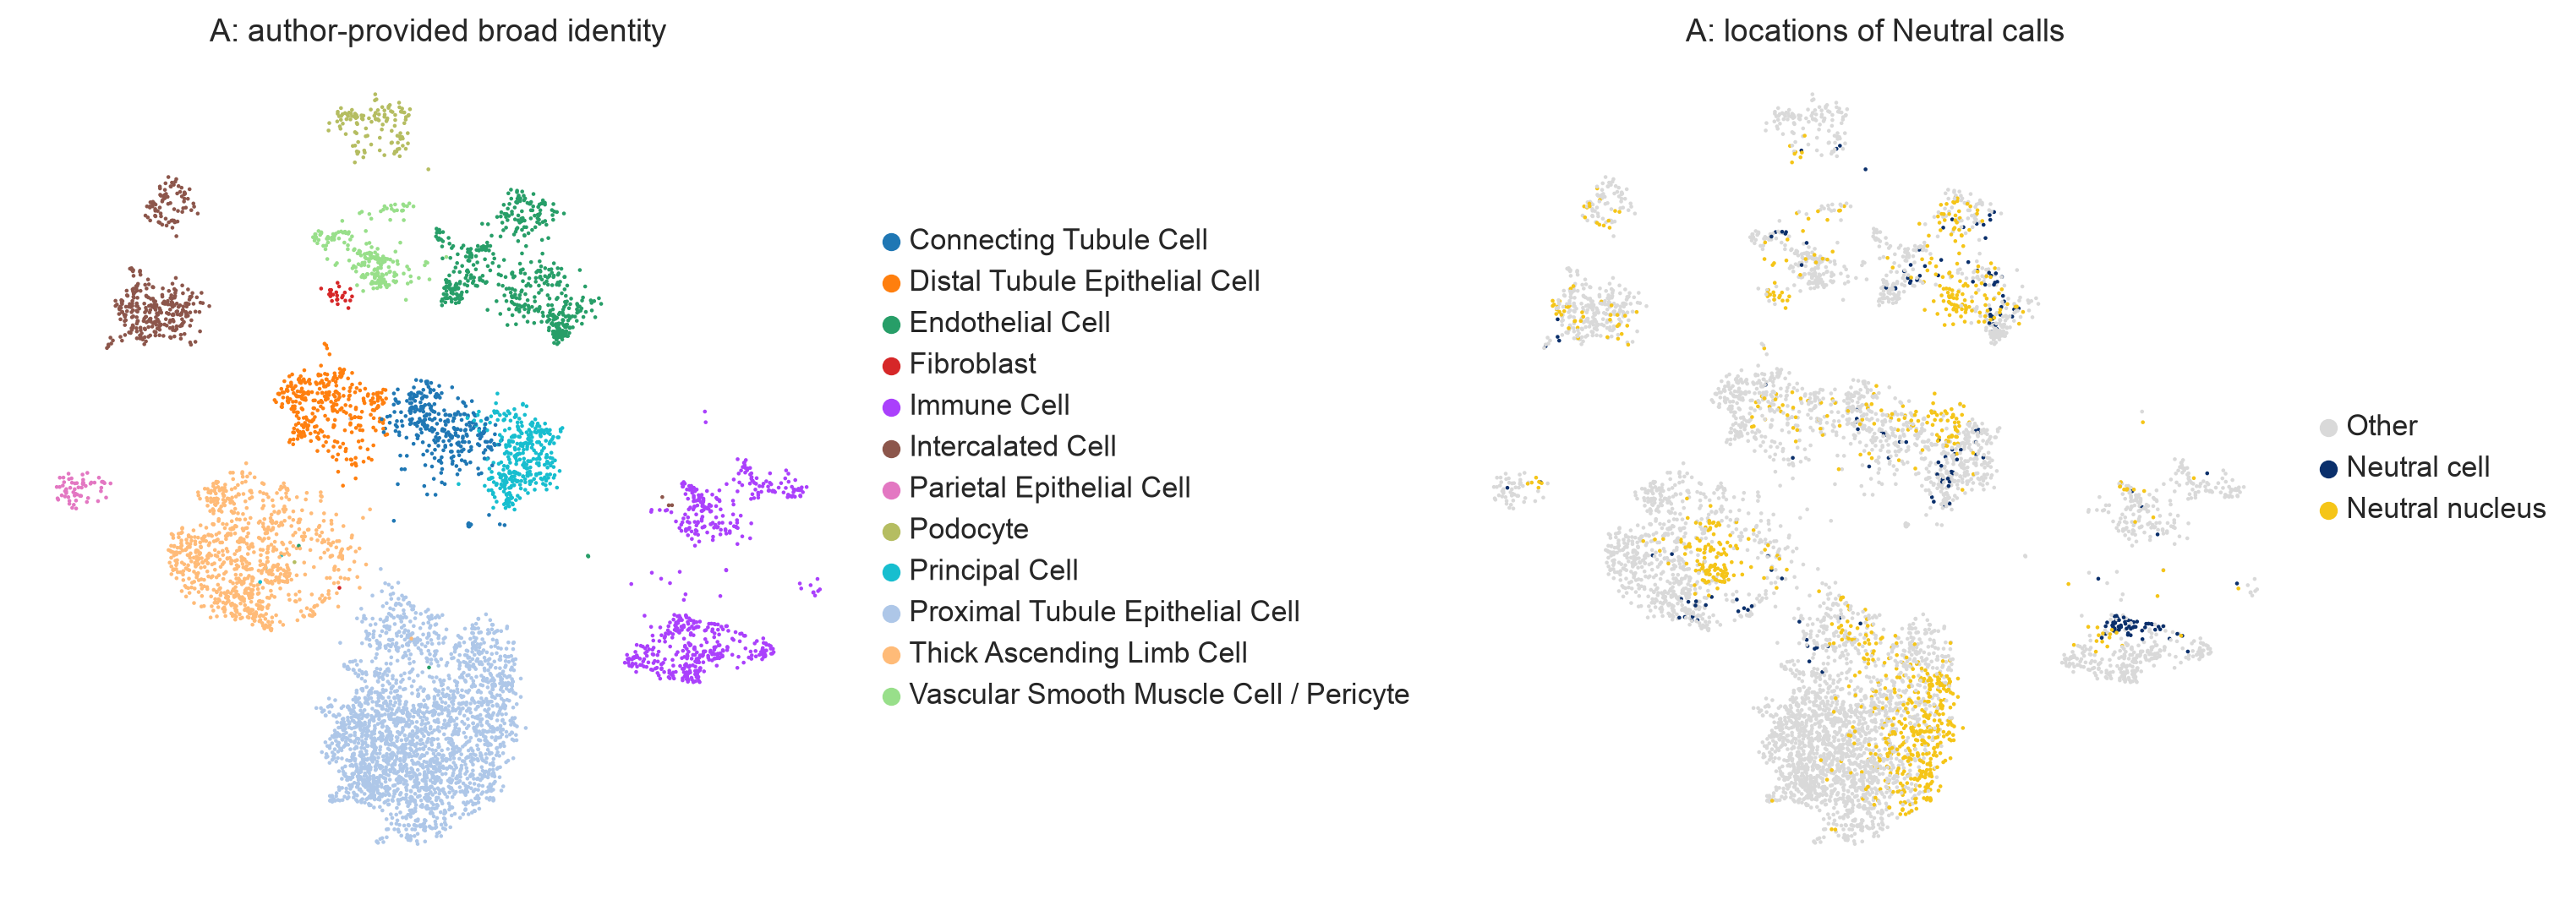

In [21]:
# Compare biological neighborhoods with the locations of Neutral calls.
q1.obs["bonus_neutral_source"] = np.select(
    [
        q1.obs["suspension_type"].astype(str).eq("cell")
        & q1.obs["modality_classification"].astype(str).eq("Neutral"),
        q1.obs["suspension_type"].astype(str).eq("nucleus")
        & q1.obs["modality_classification"].astype(str).eq("Neutral"),
    ],
    ["Neutral cell", "Neutral nucleus"],
    default="Other",
)
q1.obs["bonus_neutral_source"] = pd.Categorical(
    q1.obs["bonus_neutral_source"],
    categories=["Other", "Neutral cell", "Neutral nucleus"],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(
    q1, color="broad_cell_type", size=9,
    ax=axes[0], show=False, frameon=False,
    title="A: author-provided broad identity",
)
sc.pl.umap(
    q1, color="bonus_neutral_source",
    palette={"Other": "#d9d9d9", "Neutral cell": "#0A2F6B", "Neutral nucleus": "#F5C518"},
    size=9, ax=axes[1], show=False, frameon=False,
    title="A: locations of Neutral calls",
)
plt.tight_layout()
plt.show()

Neutral rates vary across broad identities even after cells and nuclei are analyzed separately. Among known nuclei, Immune, Fibroblast, and Endothelial groups have especially high Neutral rates and median `modality_counts` of only 4, 6, and 6. Their alignment with low signature evidence supports the Q1b count gate as a major explanation. Some known-cell groups also have elevated Neutral or discordant rates, but small groups should be interpreted cautiously.

Overall, cell identity is associated with classifier behavior, but the mechanism is not identified here. Plausible contributors include lineage-specific signature expression, differential lysis, doublets, ambient RNA, sequencing depth, and—in dataset A—the missing signature gene `AC098829.1`. The tables and UMAPs generate follow-up hypotheses; they do not prove that a high-rate identity is intrinsically nuclear or preferentially lysed.

In [22]:
assert int(bonus_b_summary["n"].sum()) == q2.n_obs
assert int(bonus_b_summary["nucleus_like_n"].sum()) == 180
assert int(bonus_a_summary["n"].sum()) == q1.n_obs
assert int(bonus_a_summary["neutral_n"].sum()) == 1151
print("Bonus consistency checks passed.")

Bonus consistency checks passed.
